Pawan Gadaum,Sami Kebebe

# Coding Documentation – Telco Customer Churn

## 1. Overview
This notebook builds a churn prediction model for a telecom dataset (Telco Customer Churn from Kaggle).  
The code follows this pipeline:
1. Load and clean the data.
2. Explore churn patterns with visualizations.
3. Build preprocessing + modeling pipelines.
4. Evaluate models with appropriate metrics.
5. Generate a ranked risk table of customers by churn probability.

## 2. Environment and Libraries
Main libraries:
- `pandas`, `numpy` for data handling
- `matplotlib`, `seaborn` for plots
- `scikit-learn` for preprocessing, modeling, and evaluation
- `imbalanced-learn` (`imblearn`) for SMOTE and pipelines

The notebook assumes these packages are installed in the Python environment.

## 3. Data Loading and Cleaning
- Load the CSV from the Telco Customer Churn dataset.
- Convert `TotalCharges` from object to numeric and coerce invalid values to `NaN`.
- Drop rows with missing `TotalCharges` if needed.
- Check dataset shape and info (`df.shape`, `df.info()`, `df.describe()`).

## 4. Exploratory Data Analysis (EDA)
- Plot churn distribution (`sns.countplot` on `Churn`).
- Examine churn vs. contract type, monthly charges, tenure, etc.
- Include short written interpretations after key plots to connect patterns to churn behavior.

## 5. Preprocessing and Feature Engineering
- Separate features and target (`Churn`).
- Identify categorical and numerical columns.
- Use `ColumnTransformer` to:
  - One-hot encode categorical variables (`OneHotEncoder(handle_unknown='ignore')`).
  - Scale numeric variables (`StandardScaler`).
- Wrap preprocessing and classifier into a `Pipeline` so that training and prediction always apply the same transformations.

## 6. Modeling
- **Baseline model:** Logistic Regression inside a pipeline.
- **Alternative model:** Random Forest (and optionally other tree-based models).
- Use cross-validation and class-balancing (e.g., SMOTE) to handle label imbalance.
- Fit models on training data and generate predictions/probabilities.

## 7. Evaluation
- Compute metrics: accuracy, precision, recall, F1-score, ROC-AUC.
- Plot confusion matrix and ROC curve.
- Interpret which metrics matter most for churn (e.g., focus on recall for catching churners).

## 8. Feature Importance and Drivers
- For Logistic Regression, inspect model coefficients after one-hot encoding to see which features increase or decrease churn odds.
- For tree-based models (e.g., Random Forest), use feature importances to see important predictors.

## 9. Risk Table and Outputs
- Combine customer IDs, true churn labels, and predicted churn probabilities.
- Create a full `risk_table` and a `top10` table of highest-risk customers.
- Save to CSV:
  - `churn_risk_table_test.csv`
  - `top10_at_risk_customers.csv`
- Optionally define a cutoff (top decile or probability threshold) to identify which customers to contact.

## 10. Reproducibility Notes
- The notebook uses fixed random seeds where possible to make results more reproducible.
- If the dataset path or environment is different, only the data loading cell needs to be updated; the rest of the pipeline remains the same.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

import pandas as pd

df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# print all column
pd.set_option('display.max_columns', None)
df.head()

100%|██████████| 172k/172k [00:00<00:00, 31.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Convert TotalCharges from object to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where conversion produced NaN (these are blank " " values)
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)


In [3]:
df.shape

(7032, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


/tmp/ipython-input-1454386121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


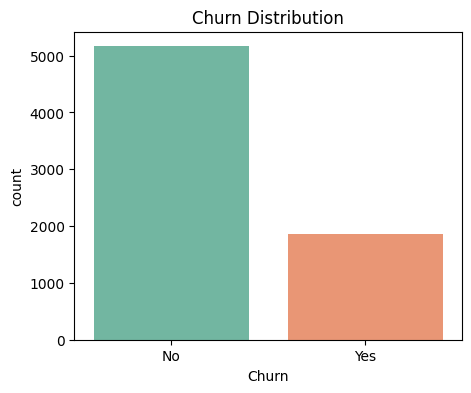

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title("Churn Distribution")
plt.show()

**Interpretation — Churn Distribution**  
- The dataset is class-imbalanced: “No” (non-churn) dominates “Yes” (churn).  
- Because of this imbalance, we should report **recall/F1/ROC-AUC** (not just accuracy) and use **stratified** splits.


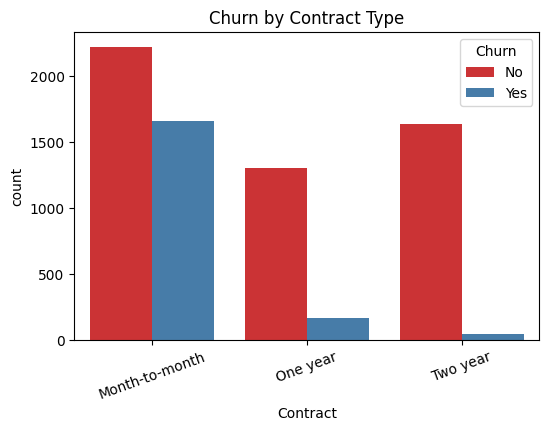

In [7]:
# Churn vs Contract Type
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

**Interpretation — Churn by Contract Type**  
- **Month-to-month** customers churn far more than 1- or 2-year contracts, indicating contracts act as a retention lever.  
- Business lever: incentives to migrate month-to-month users to **longer contracts** could reduce churn.


/tmp/ipython-input-377236805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')


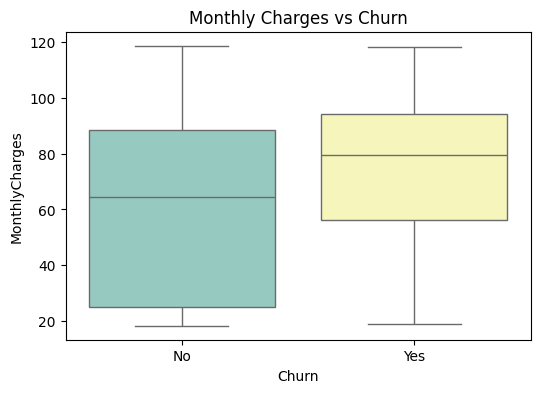

In [8]:
# Churn vs Monthly Charges
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')
plt.title("Monthly Charges vs Churn")
plt.show()

**Interpretation — Monthly Charges vs Churn**  
- Churners tend to have **higher monthly charges** (higher median and upper spread).  
- This could reflect price sensitivity or pricier service bundles; consider **targeted discounts/plan optimization** for high-charge segments.


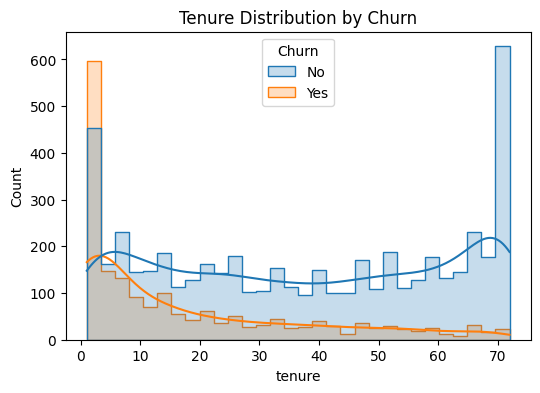

In [9]:
# Churn vs Tenure (customer length)
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, element="step")
plt.title("Tenure Distribution by Churn")
plt.show()


**Interpretation — Tenure Distribution by Churn**  
- Churn risk is **front-loaded**: customers with **low tenure** are more likely to churn.  
- Early-life cycle interventions (onboarding, proactive support, promos in the first few months) may meaningfully reduce churn.

In [10]:
# Churn rate calculation
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("Churn Rate (%):")
print(churn_rate)

Churn Rate (%):
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


#Data cleaning & splits

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Start from your existing df (already loaded)
df_clean = df.copy()


# Target to binary
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# Identify columns
id_col = 'customerID'
target = 'Churn'
feature_cols = [c for c in df_clean.columns if c not in [id_col, target]]

# Split features by type
cat_cols = [c for c in feature_cols if df_clean[c].dtype == 'object']
num_cols = [c for c in feature_cols if df_clean[c].dtype != 'object']

# Train / test split (stratified)
X_train_enc, X_test, y_train, y_test = train_test_split(
    df_clean[feature_cols], df_clean[target],
    test_size=0.2, random_state=42, stratify=df_clean[target]
)

len(X_train_enc), len(X_test), y_train.mean().round(3)


(5625, 1407, np.float64(0.266))

#Pipeline: preprocessing + Logistic Regression baseline

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Preprocess: One-hot for categoricals, scale numerics
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop=None), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # helpful for class imbalance
    solver='lbfgs'
)

pipe_lr = Pipeline(steps=[
    ('prep', preprocess),
    ('model', log_reg)
])

pipe_lr.fit(X_train_enc, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

#Evaluation: metrics, ROC-AUC, confusion matrix

Accuracy : 0.726
Precision: 0.490
Recall   : 0.797
F1-score : 0.607
ROC-AUC  : 0.835


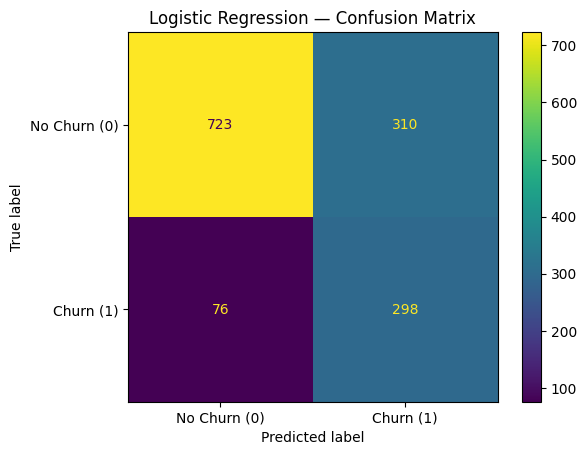

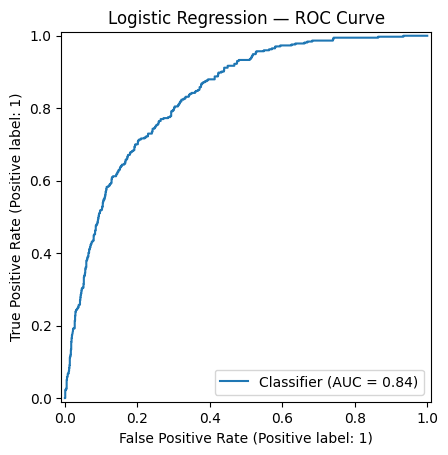


Classification Report — Logistic Regression
              precision    recall  f1-score   support

No Churn (0)       0.90      0.70      0.79      1033
   Churn (1)       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [14]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, classification_report, RocCurveDisplay,
    confusion_matrix # Import confusion_matrix
)
import matplotlib.pyplot as plt

# --- Predictions ---
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:, 1]

# --- Metrics ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {auc:.3f}")

# --- Confusion Matrix ---
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Create the display labels
display_labels = ["No Churn (0)", "Churn (1)"]
# Create and plot the ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

# --- ROC Curve (optional, nice for slides) ---
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Logistic Regression — ROC Curve")
plt.show()

# --- Classification Report ---
print("\nClassification Report — Logistic Regression")
print(classification_report(y_test, y_pred, target_names=["No Churn (0)", "Churn (1)"], zero_division=0))

**Interpretation — Baseline Model (Logistic Regression)**
- With proper preprocessing and class weighting, the model achieves solid **ROC-AUC** and balanced **Recall/F1**.
- For churn (minority class), **Recall** matters: it reflects how many actual churners we correctly flag for retention actions.


#Top drivers (feature contributions from coefficients)

In [15]:
# Get feature names after one-hot + scaling
ohe = pipe_lr.named_steps['prep'].named_transformers_['cat']
num_feats = num_cols
cat_feats = ohe.get_feature_names_out(cat_cols)
all_feats = np.concatenate([cat_feats, num_feats])

coefs = pipe_lr.named_steps['model'].coef_.ravel()
feat_importance = pd.DataFrame({'feature': all_feats, 'coef': coefs})
feat_importance['abs_coef'] = feat_importance['coef'].abs()
top20 = feat_importance.sort_values('abs_coef', ascending=False).head(20)

top20[['feature','coef']].style.background_gradient(axis=0, cmap='RdBu')


,feature,coef
42,tenure,-1.250374
34,Contract_Two year,-0.777701
32,Contract_Month-to-month,0.696066
12,InternetService_Fiber optic,0.660906
43,MonthlyCharges,-0.621137
44,TotalCharges,0.607433
11,InternetService_DSL,-0.588834
13,InternetService_No,-0.256902
18,OnlineBackup_No internet service,-0.256902
15,OnlineSecurity_No internet service,-0.256902


**Interpretation — Drivers of Churn (Logistic Coefficients)**
- Positive coefficients → increase churn odds (risk factors).
- Negative coefficients → decrease churn odds (protective factors).
- Expect to see **Month-to-month contracts**, **Fiber optic**, **High MonthlyCharges**, **No Tech Support/Online Security** as top risk indicators; **Longer contracts** and **higher tenure** as protective.


In [16]:
import pandas as pd
import numpy as np

# Transform the training data using the 'prep' step from the pipeline
X_train_processed = pipe_lr.named_steps['prep'].transform(X_train_enc)

# Get the encoder so we can grab the feature names
ohe = pipe_lr.named_steps['prep'].named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(cat_cols)

# Combine one-hot columns with numeric columns
encoded_cols = list(encoded_cat_cols) + num_cols

# Convert to DataFrame (no .toarray() since it's already dense)
X_train_encoded_df = pd.DataFrame(
    X_train_processed,
    columns=encoded_cols,
    index=X_train_enc.index
)

X_train_encoded_df.head(10)

,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
1408,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.439319,1.321816,0.981556,1.659900
6992,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.439319,-0.267410,-0.971546,-0.562252
3349,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.439319,1.444064,0.837066,1.756104
4486,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.439319,-1.204646,0.641092,-0.908326
3535,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.439319,0.669826,-0.808787,-0.101561
349,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.276251,1.281067,1.062935,1.814665
563,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.439319,-1.041649,-0.023228,-0.815638
3252,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.439319,-0.430408,0.936714,-0.063523
6539,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.439319,-0.063663,-0.353728,-0.287793
4957,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.439319,-1.082398,-0.566310,-0.877540


#Quick tree baseline for comparison

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced_subsample',
    max_depth=None
)

pipe_rf = Pipeline(steps=[('prep', preprocess), ('model', rf)])
pipe_rf.fit(X_train_enc, y_train)

y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:,1]

print("RandomForest — Test metrics")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.3f}")


RandomForest — Test metrics
Accuracy : 0.787
Precision: 0.628
Recall   : 0.484
F1-score : 0.547
ROC-AUC  : 0.814


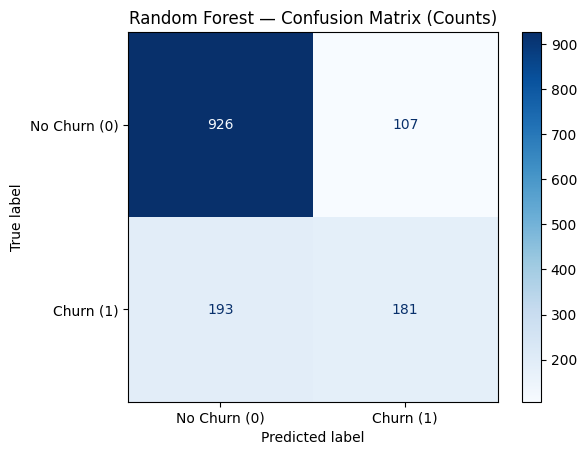

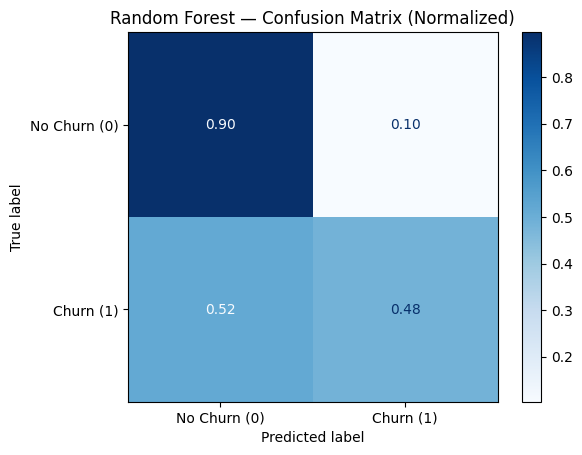


Classification Report — Random Forest
              precision    recall  f1-score   support

No Churn (0)       0.83      0.90      0.86      1033
   Churn (1)       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# --- Confusion Matrix (Counts) ---
cm = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn (0)", "Churn (1)"])
disp.plot(values_format='d', cmap='Blues')
plt.title("Random Forest — Confusion Matrix (Counts)")
plt.show()

# --- Confusion Matrix (Normalized) ---
cm_norm = confusion_matrix(y_test, y_pred_rf, labels=[0, 1], normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["No Churn (0)", "Churn (1)"])
disp_norm.plot(values_format='.2f', cmap='Blues')
plt.title("Random Forest — Confusion Matrix (Normalized)")
plt.show()

# --- Classification Report ---
print("\nClassification Report — Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["No Churn (0)", "Churn (1)"], zero_division=0))



**Takeaway — Model Comparison**
- Trees (RF) often improve **Recall/ROC-AUC** over logistic baselines by capturing non-linearities.
- Logistic is more **interpretable**; RF is often **stronger** out-of-the-box.


### Business Recommendations
- **Contract migration:** Incentivize month-to-month users to move to 1–2 year contracts (bundles, loyalty pricing).
- **Early-life interventions:** Focus on customers with **low tenure** (first 3–6 months) for onboarding and proactive support.
- **Price/plan optimization:** For high **MonthlyCharges** segments, offer tailored discounts or right-size plans.
- **Support services:** Promote **Online Security** and **Tech Support** add-ons for at-risk cohorts; they correlate with lower churn.
- **Targeted retention list:** Use model probabilities to contact the **top decile** at risk each month and track uplift.


===============================================================================
#“Top 10 at risk customers” demo
===============================================================================

#risk table (customerID + churn probability) and show Top 10

In [19]:
import pandas as pd
import numpy as np

# Make sure these exist from earlier cells:
# df_clean, id_col, X_test, pipe_lr

# Predicted churn probability on the test set
proba_test = pipe_lr.predict_proba(X_test)[:, 1]

# Map back the customer IDs using the test indices
ids_test = df_clean.loc[X_test.index, id_col].values

risk_table = pd.DataFrame({
    'customerID': ids_test,
    'churn_probability': proba_test
}).sort_values('churn_probability', ascending=False).reset_index(drop=True)

# Display Top 10 at-risk
top10 = risk_table.head(10).copy()
top10

,customerID,churn_probability
0,5150-ITWWB,0.934467
1,5178-LMXOP,0.933984
2,6861-XWTWQ,0.924494
3,1069-XAIEM,0.922343
4,6023-YEBUP,0.918260
5,9057-SIHCH,0.918046
6,2865-TCHJW,0.917972
7,4750-ZRXIU,0.917168
8,8245-UMPYT,0.909510
9,7668-XCFYV,0.909267


#horizontal bar chart

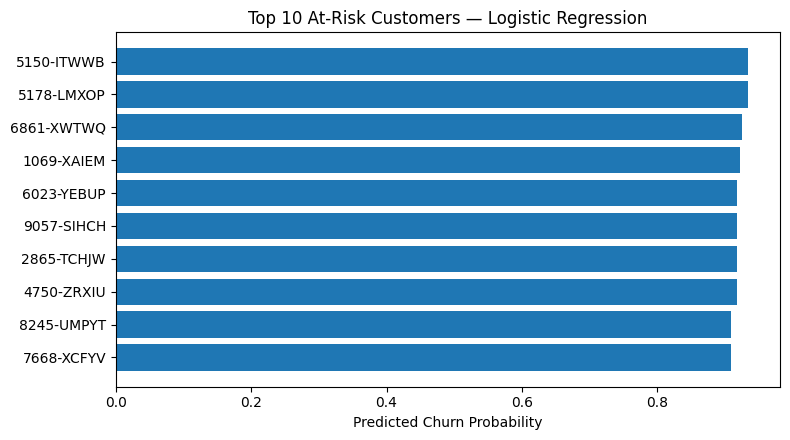

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4.5))
plt.barh(top10['customerID'][::-1], top10['churn_probability'][::-1])
plt.xlabel('Predicted Churn Probability')
plt.title('Top 10 At-Risk Customers — Logistic Regression')
plt.tight_layout()
plt.show()

#Save full risk table

In [21]:
risk_table.to_csv('churn_risk_table_test.csv', index=False)
top10.to_csv('top10_at_risk_customers.csv', index=False)

print("Saved:")
print("- churn_risk_table_test.csv (all test-set customers)")
print("- top10_at_risk_customers.csv (Top 10 only)")

Saved:
- churn_risk_table_test.csv (all test-set customers)
- top10_at_risk_customers.csv (Top 10 only)


#Choose a cutoff and show how many we would contact

In [22]:
# Example cutoffs: top decile or a probability threshold
n = len(risk_table)
top_decile_n = max(1, n // 10)

contact_list_top_decile = risk_table.head(top_decile_n)
contact_list_prob_60 = risk_table[risk_table['churn_probability'] >= 0.60]

print(f"Top decile count: {len(contact_list_top_decile)}")
print(f"Prob >= 0.60 count: {len(contact_list_prob_60)}")

Top decile count: 140
Prob >= 0.60 count: 495


In [23]:
# ============================================================
# Create encoded DataFrames using the preprocessing pipeline
# ============================================================

# Transform training and test data using the pipeline’s preprocessing step
X_train_processed = pipe_lr.named_steps['prep'].transform(X_train_enc)
X_test_processed = pipe_lr.named_steps['prep'].transform(X_test)

# Extract the one-hot encoder to get feature names
ohe = pipe_lr.named_steps['prep'].named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(cat_cols)

# Numeric columns stay the same names
encoded_num_cols = num_cols

# Combine into a single feature list
all_feature_names = list(encoded_cat_cols) + list(encoded_num_cols)

# Convert to DataFrames
import pandas as pd

X_train_encoded_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train_enc.index)
X_test_encoded_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

X_train_encoded_df.head()

,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
1408,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.439319,1.321816,0.981556,1.659900
6992,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.439319,-0.267410,-0.971546,-0.562252
3349,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.439319,1.444064,0.837066,1.756104
4486,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.439319,-1.204646,0.641092,-0.908326
3535,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.439319,0.669826,-0.808787,-0.101561


In [24]:
# ============================
# XGBOOST MODEL FOR CHURN
# ============================

!pip install xgboost --quiet

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_encoded_df, y_train)

# Predictions
xgb_preds = xgb.predict(X_test_encoded_df)
xgb_proba = xgb.predict_proba(X_test_encoded_df)[:, 1]

# Evaluate
print("=== XGBoost Performance ===")
print(classification_report(y_test, xgb_preds))
print("AUC:", roc_auc_score(y_test, xgb_proba))

# Optional confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_preds))


=== XGBoost Performance ===
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

AUC: 0.8254771678978728

Confusion Matrix:
[[906 127]
 [178 196]]


In [25]:
# ============================
# CATBOOST MODEL FOR CHURN
# ============================

!pip install catboost --quiet

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# CatBoost does well without extensive tuning
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0,
    random_state=42
)

# Train
cat.fit(X_train_encoded_df, y_train)

# Predictions
cat_preds = cat.predict(X_test_encoded_df)
cat_proba = cat.predict_proba(X_test_encoded_df)[:, 1]

# Evaluate
print("=== CatBoost Performance ===")
print(classification_report(y_test, cat_preds))
print("AUC:", roc_auc_score(y_test, cat_proba))

# Optional confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, cat_preds))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00
=== CatBoost Performance ===
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

AUC: 0.8246152372768171

Confusion Matrix:
[[907 126]
 [180 194]]


In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# 2. Clean TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["Churn"])

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()

if "customerID" in cat_cols:
    cat_cols.remove("customerID")
if "Churn" in cat_cols:
    cat_cols.remove("Churn")
if "Churn" in num_cols:
    num_cols.remove("Churn")

X = df[num_cols + cat_cols]
y = (df["Churn"] == "Yes").astype(int)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

xgb = XGBClassifier(
    n_estimators=120,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=42
)

pipe = Pipeline([("prep", preprocess), ("model", xgb)])
pipe.fit(X, y)

proba = pipe.predict_proba(X)[:, 1]
pred = (proba >= 0.5).astype(int)

df_out = df.copy()
df_out["Predicted_Prob_Churn"] = proba
df_out["Predicted_Churn_Label"] = np.where(pred == 1, "Yes", "No")

df_out.to_csv("telco_churn_with_predictions.csv", index=False)
print("Done! Generated telco_churn_with_predictions.csv")


Done! Generated telco_churn_with_predictions.csv


#NEW

# Project Plan: Telco Customer Churn Prediction

## Dataset
We are using the **Telco Customer Churn** dataset from Kaggle.  
It includes:
- **Target variable**: `Churn` (whether a customer left within the last month).  
- **Services signed up for**: Phone, Internet, Online Security, Tech Support, Streaming, etc.  
- **Account info**: Tenure, Contract type, Payment method, Paperless billing, Monthly charges, Total charges.  
- **Demographics**: Gender, Senior Citizen, Partner, Dependents.  

## Project Goal
The goal of our project is to:
1. **Predict customer churn** using classification models.  
2. **Identify key factors** that influence churn.  
3. Provide **business insights** on how telecom companies can reduce churn.  

## Planned Methodology
1. **Data Preprocessing**  
   - Handle missing values.  
   - Encode categorical variables.  
   - Normalize numerical features if needed.  

2. **Exploratory Data Analysis (EDA)**  
   - Distribution of churn.  
   - Compare churn across contract types, tenure, services, and charges.  

3. **Modeling**  
   - Baseline: Logistic Regression.  
   - Tree-based models: Decision Tree, Random Forest.  
   - Advanced: Gradient Boosting (XGBoost/LightGBM).  

4. **Evaluation Metrics**  
   - Accuracy, Precision, Recall, F1-score, ROC-AUC.  

5. **Expected Deliverables**  
   - A Jupyter notebook with analysis + models.  
   - Visualizations showing churn trends.  
   - Business recommendations to reduce churn.  
